In [1]:
from datetime import time
from os import times
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter

#math的相关函数，import后可以直接使用
from math import radians
from math import sin
from math import cos
from math import asin
from math import sqrt

# np.set_printoptions(threshold=np.inf)#显示所有的数组
from geopy.distance import great_circle
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import seaborn as sns
from scipy import stats

# from jupyterthemes import jtplot
# jtplot.style()


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def plot_change_data(years, data, ylabel, title, split_index):
    """
    根据输入的年份、数据、分割点、纵坐标标签和图表标题绘制折线图，并标注前后平均值横线。
    
    Parameters:
    years (array-like): 年份序列。
    data (array-like): 对应年份的数值数据。
    ylabel (str): 纵坐标的标签。
    title (str): 图表的标题。
    split_index (int): 数据分割点，用于划分前后部分。
    """
    # 计算分割点之前和之后的平均值
    avg_prior = np.mean(data[:split_index])
    avg_post = np.mean(data[split_index:])
    
    # 绘制数据点及连线
    plt.plot(years, data, '-o', color='red')
    
    # 绘制分割点之前数据的平均值横线
    plt.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
    
    # 绘制分割点之后数据的平均值横线
    plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
    
    # 添加坐标标签和标题
    plt.xlabel('Year', fontsize=15)
    plt.ylabel(ylabel, fontsize=15)
    plt.title(title,loc='left',fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    
    
    # 添加图例
    plt.legend(loc=1)

    
    P1 = data[:split_index]
    P2 =  data[split_index:]

    # 执行独立样本t检验，默认假设方差不等
    t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)

#     print(f"t-statistic: {t_stat}")
#     print(f"p-value: {p_value}")
    
    
    
#     x=years
#     y=data
#     #........................................................................................................   
    
#     # 计算线性回归
#     slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
#     # 计算 R 方
#     r_squared = r_value ** 2
#     ax = sns.regplot(x=x, y=y, ci=95,color='r')
# #     ax = sns.regplot(x=x, y=y, ci=95, color='r', scatter_kws={'s': 5}, line_kws={'linewidth': 1})
#     # 绘制散点图和回归线
#     plt.plot(x,y, alpha=1, linewidth=1.5,color='r')
# #     plt.plot(x, y, color='r', marker='o', linestyle='-', linewidth=1, markersize=5)

# #     plt.plot(x, intercept + slope * np.array(x), 'r')
#     print('R:',r_value)
#     print('P:', p_value)
#     print('R2:', r_squared)
    plt.title(f't: {t_stat:.2f}, P: {p_value:.2f}',loc='right',fontsize=15)
#     plt.text(1992, 1.05, f"Slope: {slope:.3f} ± {std_err:.3f}  per decade", fontsize=15, color='black')
    
    plt.show()
# split_index = 16  # 设置分割点为前16年和后24年
# plot_change_data(years, tomecur_totle, 'dist/km', 'Dist over Years', 17)
years = np.arange(1982, 2024)
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
infile = xr.open_dataset('D:/data/ibtracs/IBTrACS.WP.v04r01.nc')

In [3]:
infile

<xarray.Dataset> Size: 1GB
Dimensions:           (storm: 4176, date_time: 360, quadrant: 4)
Coordinates:
    time              (storm, date_time) datetime64[ns] 12MB ...
    lat               (storm, date_time) float32 6MB ...
    lon               (storm, date_time) float32 6MB ...
Dimensions without coordinates: storm, date_time, quadrant
Data variables: (12/159)
    numobs            (storm) float32 17kB ...
    sid               (storm) |S13 54kB ...
    season            (storm) float32 17kB ...
    number            (storm) int16 8kB ...
    basin             (storm, date_time) |S2 3MB ...
    subbasin          (storm, date_time) |S2 3MB ...
    ...                ...
    reunion_gust      (storm, date_time) float32 6MB ...
    reunion_gust_per  (storm, date_time) float32 6MB ...
    usa_seahgt        (storm, date_time) float32 6MB ...
    usa_searad        (storm, date_time, quadrant) float32 24MB ...
    storm_speed       (storm, date_time) float32 6MB ...
    storm_dir         (storm, date_time) float32 6MB ...
Attributes: (12/49)
    title:                      IBTrACS - International Best Track Archive fo...
    summary:                    The intent of the IBTrACS project is to overc...
    source:                     The original data are tropical cyclone positi...
    Conventions:                ACDD-1.3
    Conventions_note:           Data are nearly CF-1.7 compliant. The sole is...
    product_version:            v04r01
    ...                         ...
    history:                    Tue Sep 24 05:54:34 2024: ncks --no_abc --cnk...
    license:                    These data may be redistributed and used with...
    featureType:                trajectory
    cdm_data_type:              Trajectory
    comment:                    The tracks of TCs generally look like a traje...
    NCO:                        netCDF Operators version 5.0.7 (Homepage = ht...

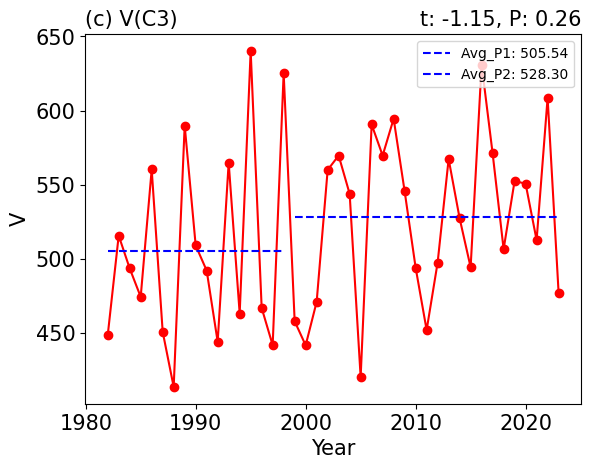

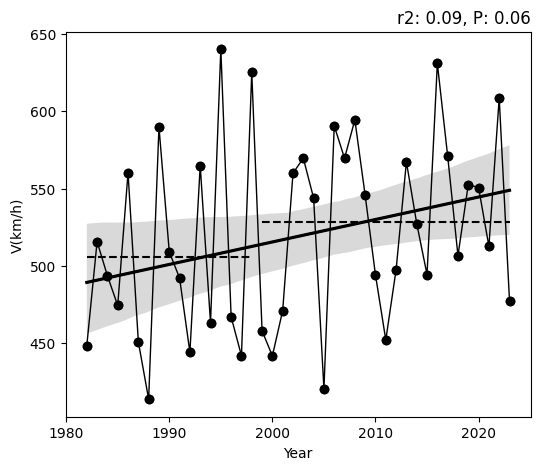

R: 0.29195264297274537
P: 0.06064526987668452
R2: 0.08523634573877133


In [4]:

# 读取数据
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')

# 要去掉的 Typhoon ID


tomecur = []

for year in range(1982, 2024):  # 包括1982到2023年
    # 提取当前年份的数据
    year_data = df[df['year'] == year]
    
    # 获取该年份所有的 Typhoon ID，并去掉 3020
    indall = year_data['Typhoon ID'].unique()
    
    numatc = indall.shape[0]

   
 
    lat=infile['usa_lat'][indall]#筛选的结果
    lon=infile['usa_lon'][indall]   
    win=infile['usa_wind'][indall]
    tocur=[]
    for i in range(0,numatc):#一年的登陆台风曲率
        arrlat= np.array([num for num in lat[i].values if not np.isnan(num)])#将非nan存在新的数组中,一个新的数组
        arrlon= np.array([num for num in lon[i].values if not np.isnan(num)])
        arrwin= np.array([num for num in win[i].values if not np.isnan(num)])
        orilat=arrlat[0]
        endlat=arrlat[-1]
        
        orilon=arrlon[0]
        endlon=arrlon[-1]
       
        ori=[orilat,orilon]#起点集合
        end=[endlat,endlon]
        dist=great_circle(ori, end).kilometers#起点和终点的距离
        if dist!=0:
        
            coor=np.column_stack((arrlat, arrlon))#合并经纬度
            time=(len(arrlat)-1)/8
            todist=0#总距离todist
            for k in range(len(coor) - 1):
                distall = great_circle(coor[k], coor[k+1]).kilometers
                todist += distall
            cur=todist/time#一个台风的曲率
            
                
            
           
            tocur.append(cur)
   
    mecur=np.mean(tocur)#平均曲率
    tomecur.append(mecur)

        

y = tomecur


plot_change_data(years, y, 'V', '(c) V(C3)', 17)

ccc=y
#........................................................................................................       
x=[]#年份
for l in range(1982,2024):
    x.append(l)
y=tomecur
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
plt.xlabel('Year')
plt.ylabel('V(km/h)')
split_index=17
plt.title(f'r2: {r_squared:.2f}, P: {p_value:.2f}',loc='right',fontsize=12)
data=y
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
split_index=17
# 绘制数据点及连线
# plt.plot(years, data, '-o', color='red')

# 绘制分割点之前数据的平均值横线
plt.plot(years[:split_index], [avg_prior] * split_index, color='k', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')

# 绘制分割点之后数据的平均值横线
plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='k', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)

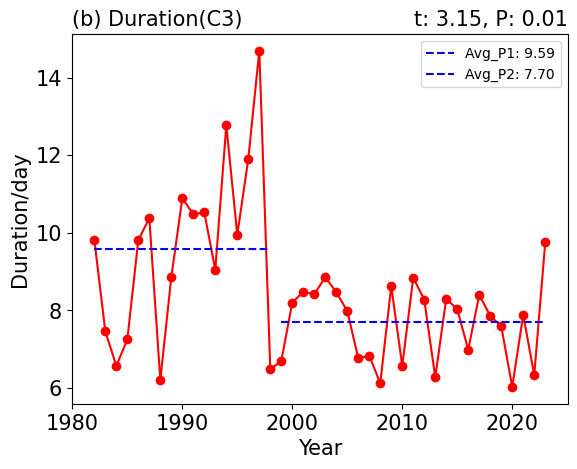

In [5]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')



tomecur1 = []
tonccur = []

for year in range(1982, 2024):  # 包括1982到2023年
    # 提取当前年份的数据
    year_data = df[df['year'] == year]
    
    # 获取该年份所有的 Typhoon ID，并去掉 3020
    indall = year_data['Typhoon ID'].unique()
   
    numatc = indall.shape[0]

    lat = infile['usa_lat'][indall]  # 筛选的结果
    lon = infile['usa_lon'][indall]
    tocur = []
    
    for i in range(0, numatc):  # 一年的登陆台风曲率
        arrlat = np.array([num for num in lat[i].values if not np.isnan(num)])  # 将非nan存在新的数组中
        arrlon = np.array([num for num in lon[i].values if not np.isnan(num)])
        dura = (arrlat.shape[0] - 1) / 8
        cur = dura
        tocur.append(cur)
    
    mecur = np.mean(tocur)  # 平均曲率
    tomecur1.append(mecur)  # 40年平均曲率
    
c3duration = tomecur1

plot_change_data(years, c3duration, 'Duration/day', '(b) Duration(C3)', 17)

In [6]:
c3duration

[np.float64(9.825),
 np.float64(7.458333333333333),
 np.float64(6.571428571428571),
 np.float64(7.25),
 np.float64(9.8125),
 np.float64(10.375),
 np.float64(6.204545454545454),
 np.float64(8.854166666666666),
 np.float64(10.88888888888889),
 np.float64(10.48076923076923),
 np.float64(10.525),
 np.float64(9.045454545454545),
 np.float64(12.7734375),
 np.float64(9.946428571428571),
 np.float64(11.902777777777779),
 np.float64(14.6875),
 np.float64(6.482142857142857),
 np.float64(6.694444444444445),
 np.float64(8.201923076923077),
 np.float64(8.479166666666666),
 np.float64(8.416666666666666),
 np.float64(8.854166666666666),
 np.float64(8.46875),
 np.float64(7.984375),
 np.float64(6.767857142857143),
 np.float64(6.828125),
 np.float64(6.125),
 np.float64(8.625),
 np.float64(6.571428571428571),
 np.float64(8.84375),
 np.float64(8.278846153846153),
 np.float64(6.2727272727272725),
 np.float64(8.305555555555555),
 np.float64(8.025),
 np.float64(6.988636363636363),
 np.float64(8.4027777777777

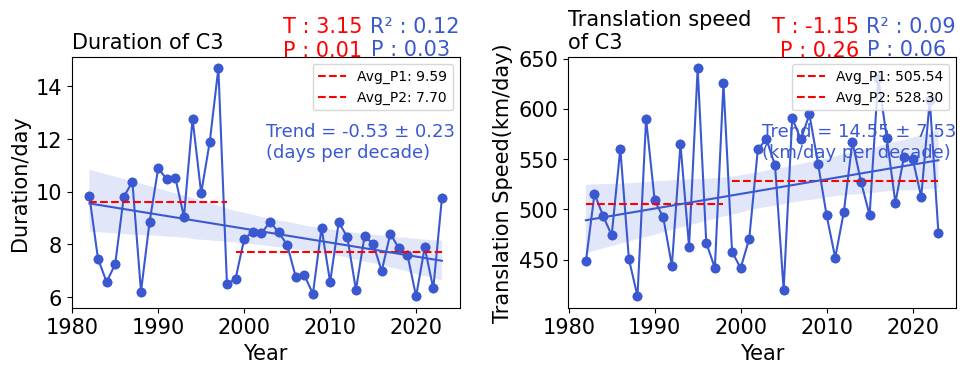

In [12]:
color1='#3A59D1'
color2=color1
color3='r'
fig, axes = plt.subplots(1,2, figsize=(10, 4))
fig.subplots_adjust(top=1,bottom=0,hspace=0.3)
ax=axes[1]
split_index=17
data=tomecur
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color=color1)
ax.plot(years[:split_index], [avg_prior] * split_index, color=color3, linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color=color3, linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Translation Speed(km/day)', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value2 = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('Translation speed \nof C3',loc='left',fontsize=15)
x=years
y=data
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
sns.regplot(x=x, y=y, ci=95,color=color2,ax=ax, line_kws={"linewidth": 1.5})
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
ax.text(0.5,0.6,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} \n(km/day per decade)",
        fontsize=13,c=color2,
       transform=ax.transAxes)
ax.text(0.75, 1.16, f'T : {t_stat:.2f}\nP : {p_value2:.2f}', ha='right', va='top', fontsize=15, color=color3, transform=ax.transAxes)
ax.text(1, 1.16, f'R² : {r_squared:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)
ax.text(0.975, 1.07, f'P : {p_value:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)


ax=axes[0]
split_index=17
data=tomecur1
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color=color1)
ax.plot(years[:split_index], [avg_prior] * split_index, color=color3, linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color=color3, linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Duration/day', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value2 = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('Duration of C3',loc='left',fontsize=15)
x=years
y=data
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
sns.regplot(x=x, y=y, ci=95,color=color2,ax=ax, line_kws={"linewidth": 1.5})
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
ax.text(0.5,0.6,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} \n(days per decade)",
        fontsize=13,c=color2,
       transform=ax.transAxes)
ax.text(0.75, 1.16, f'T : {t_stat:.2f}\nP : {p_value2:.2f}', ha='right', va='top', fontsize=15, color=color3, transform=ax.transAxes)
ax.text(1, 1.16, f'R² : {r_squared:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)
ax.text(0.975, 1.07, f'P : {p_value:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)

plt.tight_layout()
plt.savefig("Figure S5.pdf",transparent = True)
plt.show()

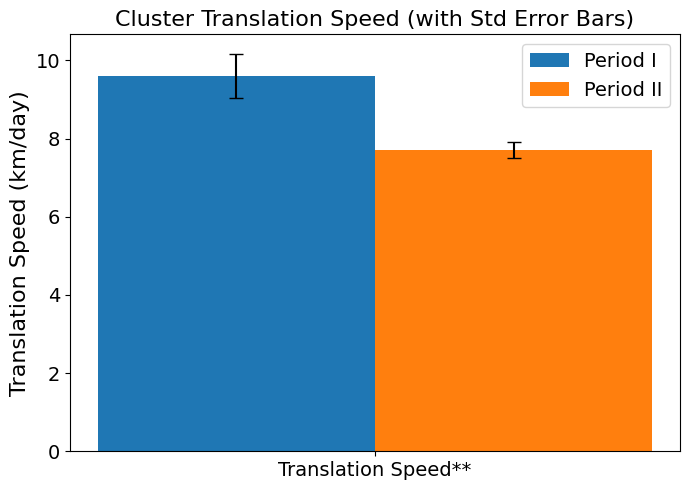

In [10]:
import numpy as np
import matplotlib.pyplot as plt



DU = tomecur1

# ==== 按时期划分 ====
period1_mask = (years >= 1982) & (years <= 1998)
period2_mask = (years >= 1999) & (years <= 2023)

data_period1 = np.vstack([DU[:17]])
data_period2 = np.vstack([DU[17:]])

# ==== 计算平均值与标准差（误差棒使用标准差 SD） ====
mean1 = data_period1.mean(axis=1)
mean2 = data_period2.mean(axis=1)
std1 = data_period1.std(axis=1, ddof=1) / np.sqrt(data_period1.shape[1])
std2 = data_period2.std(axis=1, ddof=1) / np.sqrt(data_period2.shape[1])


# ==== 画柱状图 + 误差棒 ====
labels = ['Translation Speed**']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7,5))

bars1 = ax.bar(x - width/2, mean1, width, yerr=std1, capsize=5, label='Period I')
bars2 = ax.bar(x + width/2, mean2, width, yerr=std2, capsize=5, label='Period II')

ax.set_ylabel("Translation Speed (km/day)", fontsize=16)
ax.tick_params(axis='y', labelsize=14)   # y 轴刻度字体大小改为 14
ax.set_title("Cluster Translation Speed (with Std Error Bars)", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=14)   # 修改成你想要的字号
ax.legend(fontsize=14)   # 调整图例文字大小


plt.tight_layout()
plt.savefig("Figure S3c.pdf",transparent = True)
plt.show()


In [13]:
tomecur

[np.float64(448.3194329526118),
 np.float64(515.66647927071),
 np.float64(493.5788857961126),
 np.float64(474.35712402980425),
 np.float64(560.2749367942222),
 np.float64(450.8437097961754),
 np.float64(413.6386390966723),
 np.float64(589.9364608489435),
 np.float64(509.037077997781),
 np.float64(492.08880930714474),
 np.float64(444.05204053462535),
 np.float64(564.8929329666906),
 np.float64(463.15104439715475),
 np.float64(640.2347540531919),
 np.float64(466.9370557953008),
 np.float64(441.8008208066506),
 np.float64(625.3065833221972),
 np.float64(457.9369568542783),
 np.float64(441.6891554247412),
 np.float64(471.03271164493964),
 np.float64(559.9669946496894),
 np.float64(569.6841299221433),
 np.float64(543.8540188005423),
 np.float64(420.1779774146395),
 np.float64(590.6167487262677),
 np.float64(569.651577636303),
 np.float64(594.4873927292692),
 np.float64(545.6025136252315),
 np.float64(494.0481986938591),
 np.float64(452.01123688718815),
 np.float64(497.4981474903094),
 np.fl